# CAPSTONE: Pardavimų ir klientų elgsenos analizė (Supermarket Sales)

**Duomenų rinkinys:** Supermarket Sales 
https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales



In [1]:
# importuojame reikalingas bibliotekas
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Regresijai
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


## 1. Duomenų įkėlimas

TO DO:
- Įkelti CSV failą.
- Patikrinti, ar `df` egzistuoja ir ar matosi pirmos eilutės.


In [2]:
# Įkeliame duomenis:
df = pd.read_csv(r"C:\Users\migle\Desktop\BIT kursai\03_Python\SuperMarket Analysis.csv")

df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Duomenų supratimas ir paruošimas

In [3]:
# Patikriname duomenų dydį ir turimus stulpelius:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1000, 17)
Columns: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [4]:
# Patikriname duomenų tipus:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [5]:
# Duomenų tipai kiekviename stulpelyje:
df.dtypes

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [6]:
# Tikriname, ar duomenys turi trūkstamų reikšmių (neturi):
df.isna().sum().sort_values(ascending=False)


Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [7]:
# Konvertuojame datą 
df["Date"] = pd.to_datetime(df["Date"])
df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"], format="mixed")
df.insert(df.columns.get_loc("Time") + 1, "Datetime", df.pop("Datetime"))

print("Atnaujinti duomenų tipai:\n")
print(df.dtypes)
print()

print("Atnaujinti duomenys:\n")
df.head()



Atnaujinti duomenų tipai:

Invoice ID                            str
Branch                                str
City                                  str
Customer type                         str
Gender                                str
Product line                          str
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[us]
Time                                  str
Datetime                   datetime64[us]
Payment                               str
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

Atnaujinti duomenys:



,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Datetime,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,2019-01-05 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,2019-03-08 10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,2019-03-03 13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,2019-01-27 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,2019-02-08 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


## 3. Aprašomoji analizė (EDA)

In [8]:
# Išsiaiškiname Sales, Quantity, Rating, Gross income mean, median, std, min, max:
numeric_stats = df[["Sales", "Quantity", "Rating", "gross income"]].describe().T
print("Pagrindinės statistikos:")
print(numeric_stats)


Pagrindinės statistikos:
               count        mean         std      min         25%      50%  \
Sales         1000.0  322.966749  245.885335  10.6785  124.422375  253.848   
Quantity      1000.0    5.510000    2.923431   1.0000    3.000000    5.000   
Rating        1000.0    6.972700    1.718580   4.0000    5.500000    7.000   
gross income  1000.0   15.379369   11.708825   0.5085    5.924875   12.088   

                    75%      max  
Sales         471.35025  1042.65  
Quantity        8.00000    10.00  
Rating          8.50000    10.00  
gross income   22.44525    49.65  


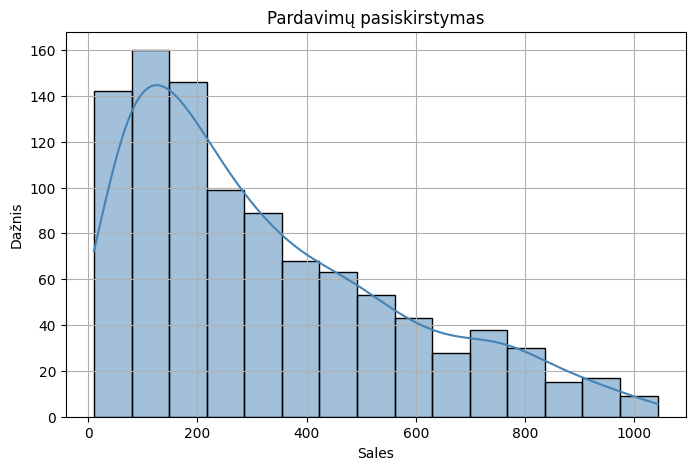

Pardavimai pasiskirstę dešinę pusę (right-skewed): dauguma pirkimo krepšelių yra smulkūs,
  tačiau yra reikšmingų didelių pirkimų, kurie kelia vidurkį.


In [9]:
# 2. Grafikas 1 Pardavimų pasiskirstymas

plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], kde=True, color="steelblue")
plt.title("Pardavimų pasiskirstymas")
plt.xlabel("Sales")
plt.ylabel("Dažnis")
plt.show()

print("Pardavimai pasiskirstę dešinę pusę (right-skewed): dauguma pirkimo krepšelių yra smulkūs,")
print("  tačiau yra reikšmingų didelių pirkimų, kurie kelia vidurkį.")


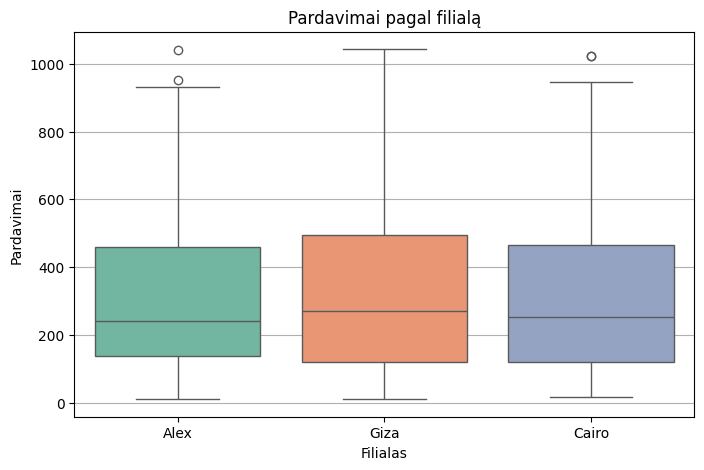

Visų trijų filialų (Alex, Cairo, Giza) pardavimų medianos panašios.


In [10]:
# Grafikas Nr2, Palyginimas tarp filialų (branches)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Branch", y="Sales", hue="Branch", palette="Set2", legend=False)
plt.title("Pardavimai pagal filialą")
plt.xlabel("Filialas")
plt.ylabel("Pardavimai")
plt.show()

print("Visų trijų filialų (Alex, Cairo, Giza) pardavimų medianos panašios.")


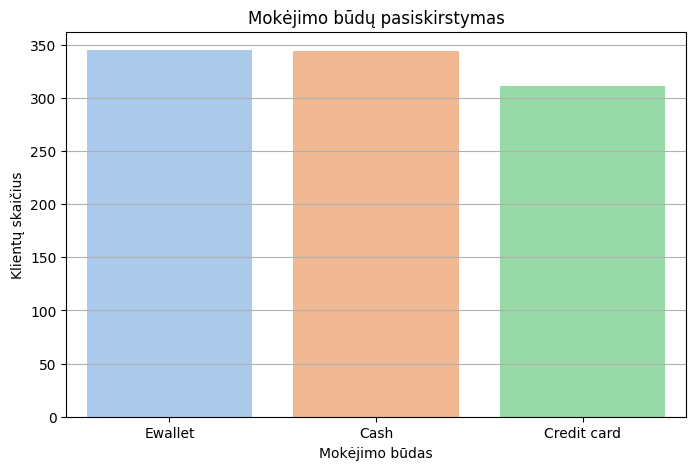

Matome, kad visi trys mokėjimo būdai naudojami panašiu dažnumu.
Atsiskaitymai kreditine kortele šiek tiek retesni, negu grynais arba e-pinigine.


In [11]:
# Grafikas 3 – Mokėjimų būdo pasiskirstymas


plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Payment", hue="Payment", palette="pastel", legend=False)
plt.title("Mokėjimo būdų pasiskirstymas")
plt.xlabel("Mokėjimo būdas")
plt.ylabel("Klientų skaičius")
plt.show()

print("Matome, kad visi trys mokėjimo būdai naudojami panašiu dažnumu.")
print("Atsiskaitymai kreditine kortele šiek tiek retesni, negu grynais arba e-pinigine.")


## 4. 95 % pasikliautinis intervalas (CI)


Kintamasis: Sales
Imties dydis: n = 1000
Vidurkis: 322.97
Std. nuokrypis: 245.89
Std. paklaida: 7.78
t (kritinis): 1.9623
─────────────
95 % PI: [307.71 ; 338.23]


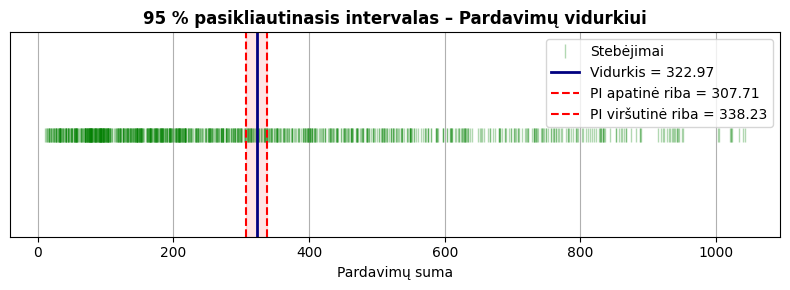


Esame 95 % tikri, kad tikrasis vidutinis pardavimų dydis
patenka tarp 307.71 ir 338.23 verčių.
Tai reiškia, kad tipiškas pirkimas parduotuvėje vidutiniškai svyruoja tarp ~308–338.


In [12]:
from scipy.stats import t

col = "Sales"
x = df[col].dropna().astype(float).values
n = len(x)
mean_val = x.mean()
std_val  = x.std(ddof=1)
se       = std_val / np.sqrt(n)

alpha   = 0.05
t_crit  = t.ppf(1 - alpha / 2, df=n - 1)
ci_low  = mean_val - t_crit * se
ci_high = mean_val + t_crit * se

print(f"Kintamasis: {col}")
print(f"Imties dydis: n = {n}")
print(f"Vidurkis: {mean_val:.2f}")
print(f"Std. nuokrypis: {std_val:.2f}")
print(f"Std. paklaida: {se:.2f}")
print(f"t (kritinis): {t_crit:.4f}")
print(f"─────────────")
print(f"95 % PI: [{ci_low:.2f} ; {ci_high:.2f}]")

# Grafikas
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x, np.zeros_like(x), '|', color='green', alpha=0.3, markersize=10, label="Stebėjimai")
ax.axvline(mean_val, color='navy', linewidth=2, label=f"Vidurkis = {mean_val:.2f}")
ax.axvline(ci_low,  color='red', linestyle='--', linewidth=1.5, label=f"PI apatinė riba = {ci_low:.2f}")
ax.axvline(ci_high, color='red', linestyle='--', linewidth=1.5, label=f"PI viršutinė riba = {ci_high:.2f}")
ax.axvspan(ci_low, ci_high, alpha=0.1, color='red')
ax.set_title("95 % pasikliautinasis intervalas – Pardavimų vidurkiui", fontsize=12, fontweight="bold")
ax.set_xlabel("Pardavimų suma")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

print()
print(f"Esame 95 % tikri, kad tikrasis vidutinis pardavimų dydis")
print(f"patenka tarp {ci_low:.2f} ir {ci_high:.2f} verčių.")
print(f"Tai reiškia, kad tipiškas pirkimas parduotuvėje vidutiniškai svyruoja tarp ~{ci_low:.0f}–{ci_high:.0f}.")

## 5. Hipotezių testavimas (H0 ir Ha)


T-TESTAS: Sales vidurkis – Member vs Normal klientai
H₀: Vidutiniai pardavimai Member ir Normal klientams VIENODI
Hₐ: Vidutiniai pardavimai skiriasi

Member  → n=565, vidurkis=335.74, std=250.42
Normal  → n=435, vidurkis=306.37, std=239.14

t statistika : 1.8862
p reikšmė    : 0.0596

✓ H₀ neatmetame (p ≥ 0.05): nėra pakankamo pagrindo teigti, kad vidurkiai skiriasi.


C:\Users\migle\AppData\Local\Temp\ipykernel_27500\594657576.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Customer type", y="Sales", palette=["#4C72B0", "#DD8452"], ax=ax)


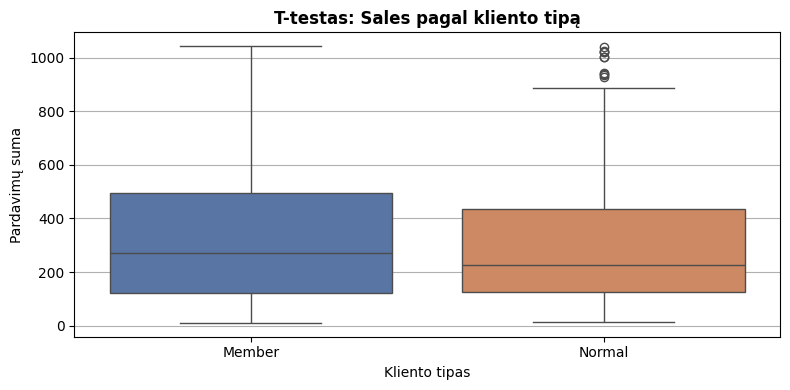

In [18]:
print("T-TESTAS: Sales vidurkis – Member vs Normal klientai")
print("H₀: Vidutiniai pardavimai Member ir Normal klientams VIENODI")
print("Hₐ: Vidutiniai pardavimai skiriasi\n")

g_member = df.loc[df["Customer type"] == "Member", "Sales"].dropna().astype(float)
g_normal = df.loc[df["Customer type"] == "Normal", "Sales"].dropna().astype(float)

t_stat, p_val = stats.ttest_ind(g_member, g_normal, equal_var=False)

print(f"Member  → n={len(g_member)}, vidurkis={g_member.mean():.2f}, std={g_member.std():.2f}")
print(f"Normal  → n={len(g_normal)}, vidurkis={g_normal.mean():.2f}, std={g_normal.std():.2f}")
print(f"\nt statistika : {t_stat:.4f}")
print(f"p reikšmė    : {p_val:.4f}")
print()
if p_val < 0.05:
    print("✗ H₀ atmetame (p < 0.05): pardavimų vidurkiai statistiškai reikšmingai SKIRIASI.")
else:
    print("✓ H₀ neatmetame (p ≥ 0.05): nėra pakankamo pagrindo teigti, kad vidurkiai skiriasi.")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="Customer type", y="Sales", palette=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("T-testas: Sales pagal kliento tipą", fontsize=12, fontweight="bold")
ax.set_xlabel("Kliento tipas")
ax.set_ylabel("Pardavimų suma")
plt.tight_layout()
plt.show()

## 6. Regresinė analizė (privaloma)


In [14]:
import sklearn

In [15]:
# Pasirenkame kintamuosius
target = "Sales"
features = ["Unit price", "Quantity", "Customer type", "Gender", "Payment"]

X_raw = df[features].copy()
y = df[target].astype(float)

# Paverčiame kategorinius į skaičius (Dummy variables)
X = pd.get_dummies(X_raw, drop_first=True).astype(float)

# Modelio mokymas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Vertinimas
pred = model.predict(sm.add_constant(X_test))
print(f"R-squared: {r2_score(y_test, pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred):.2f}")
model.summary()

R-squared: 0.9033
MAE: 58.95


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     1036.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:00:51   Log-Likelihood:                -4658.8
No. Observations:                 800   AIC:                             9332.
Df Residuals:                     793   BIC:                             9364.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -323.3965     10.357    -31.225      0.000    -343.727    -303.066
Unit price               5.8085      0.111     52.426      0.000       5.591       6.026
Quantity                58.0960      0.991     58.623      0.000      56.151      60.041
Customer type_Normal     6.2988      5.922      1.064      0.288      -5.326      17.923
Gender_Male             -9.0730      5.969     -1.520      0.129     -20.790       2.644
Payment_Credit card      9.8600      7.182      1.373      0.170      -4.238      23.958
Payment_Ewallet         -1.5014      7.037     -0.213      0.831     -15.314      12.311
==============================================================================
Omnibus:                        0.164   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.921   Jarque-Bera (JB):                0.096
Skew:                          -0.020   Prob(JB):                        0.953
Kurtosis:                       3.035   Cond. No.                         243.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

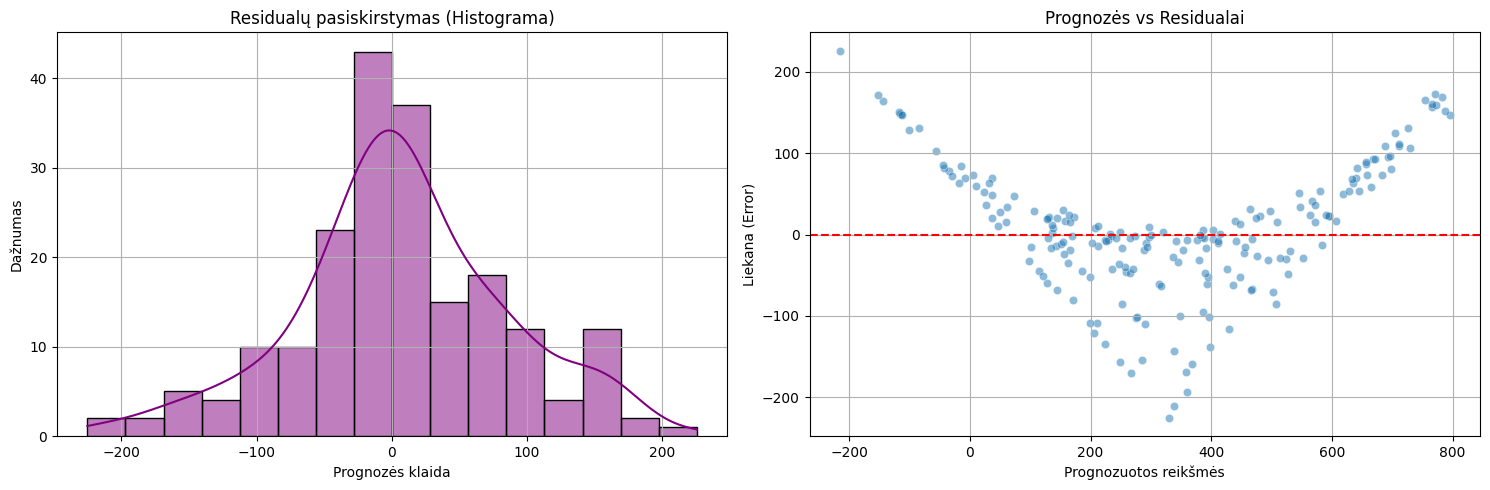

In [16]:
# 1. Apskaičiuojame liekanas (tikros reikšmės minus prognozė)
residuals = y_test - pred

# Sukuriame grafikų langą (du grafikai šalia)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Pirmas grafikas: Residualų pasiskirstymas (Histograma)
sns.histplot(residuals, kde=True, ax=ax[0], color="purple")
ax[0].set_title('Residualų pasiskirstymas (Histograma)')
ax[0].set_xlabel('Prognozės klaida')
ax[0].set_ylabel('Dažnumas')

# Antras grafikas: Predicted vs Residuals (Išsibarstymas)
sns.scatterplot(x=pred, y=residuals, ax=ax[1], alpha=0.5)
ax[1].axhline(y=0, color='red', linestyle='--') # Nulinė linija
ax[1].set_title('Prognozės vs Residualai')
ax[1].set_xlabel('Prognozuotos reikšmės')
ax[1].set_ylabel('Liekana (Error)')

plt.tight_layout()
plt.show()

## 7. Laiko eilučių analizė


Laiko eilutė (pirmos/paskutinės 5 dienos):
                Sales
Date                 
2019-01-01  4745.1810
2019-01-02  1945.5030
2019-01-03  2078.1285
2019-01-04  1623.6885
2019-01-05  3536.6835
2019-03-26  1962.5130
2019-03-27  2902.8195
2019-03-28  2229.4020
2019-03-29  4023.2430
2019-03-30  4487.0595


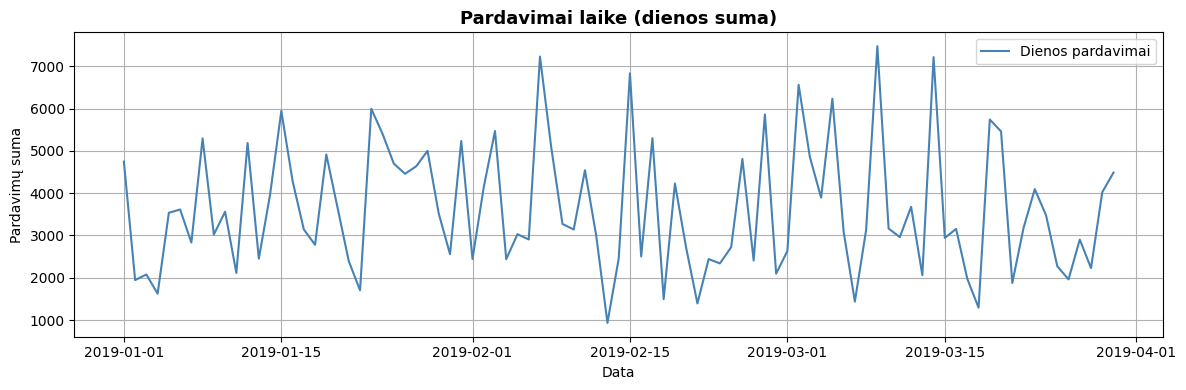

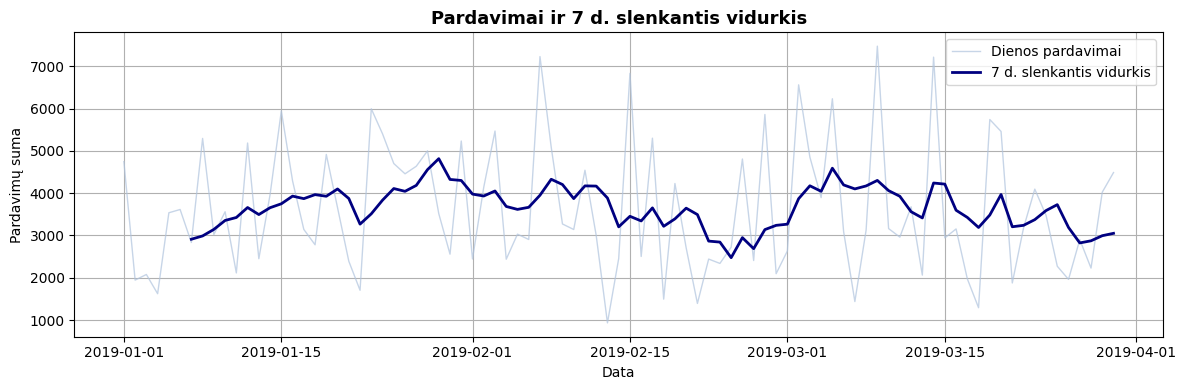

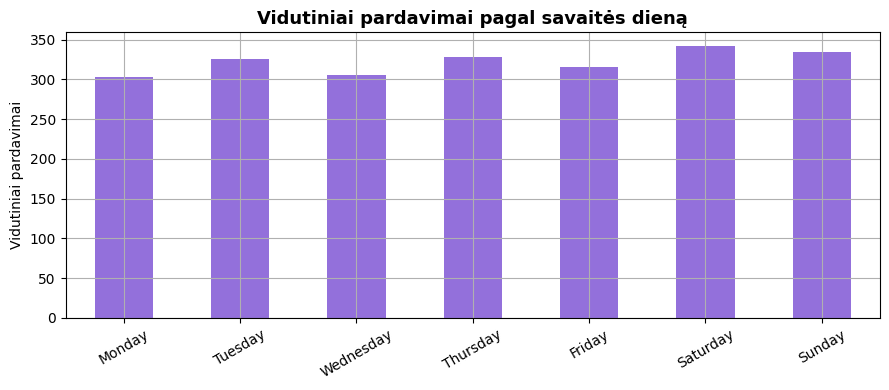

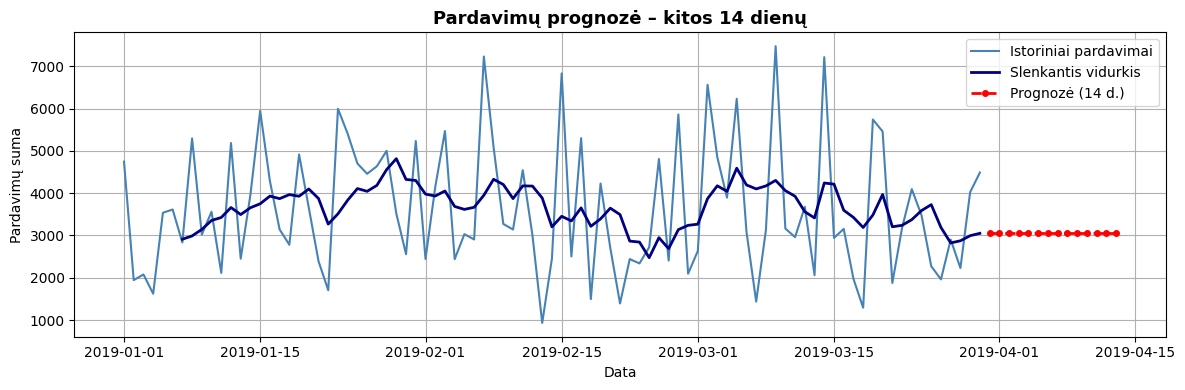

Laiko eilučių analizės išvados:
Pardavimai pasiskirstę daugmaž tolygiai viso periodo metu.
Nėra ryškaus sezoniškumo dėl gana trumpo duomenų periodo (3 mėn.).
Slenkančio vidurkio prognozė kitoms 14 dienų: ~3051 vnt./dieną.


In [17]:
# Laiko eilutė: dienos pardavimų suma
ts = df.groupby("Date")["Sales"].sum().sort_index()
ts.index = pd.DatetimeIndex(ts.index)

print("Laiko eilutė (pirmos/paskutinės 5 dienos):")
print(pd.concat([ts.head(), ts.tail()]).to_frame())

# Grafikas 1 – pardavimų dinamika
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts.index, ts.values, color="steelblue", linewidth=1.5, label="Dienos pardavimai")
ax.set_title("Pardavimai laike (dienos suma)", fontsize=13, fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("Pardavimų suma")
ax.legend()
plt.tight_layout()
plt.show()

# Grafikas 2 – slenkantis vidurkis (7 d.)
window = 7
ts_ma = ts.rolling(window=window).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts.index, ts.values,    color="lightsteelblue", linewidth=1, alpha=0.7, label="Dienos pardavimai")
ax.plot(ts_ma.index, ts_ma.values, color="navy", linewidth=2, label=f"{window} d. slenkantis vidurkis")
ax.set_title("Pardavimai ir 7 d. slenkantis vidurkis", fontsize=13, fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("Pardavimų suma")
ax.legend()
plt.tight_layout()
plt.show()

# Grafikas 3 – pardavimai pagal savaitės dieną
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["DayOfWeek"] = pd.Categorical(df["Date"].dt.day_name(), categories=dow_order, ordered=True)
dow_avg = df.groupby("DayOfWeek", observed=True)["Sales"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
dow_avg.plot(kind="bar", color="mediumpurple", ax=ax)
ax.set_title("Vidutiniai pardavimai pagal savaitės dieną", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Vidutiniai pardavimai")
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Prognozė: kitos 14 dienų slenkančiu vidurkiu
last_ma = ts_ma.dropna().iloc[-1]
future_dates = pd.date_range(ts.index[-1] + pd.Timedelta(days=1), periods=14)
forecast = pd.Series([last_ma] * 14, index=future_dates)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts.index,      ts.values,       color="steelblue", linewidth=1.5, label="Istoriniai pardavimai")
ax.plot(ts_ma.index,   ts_ma.values,    color="navy",      linewidth=2,   label="Slenkantis vidurkis")
ax.plot(forecast.index, forecast.values, color="red", linestyle="--", linewidth=2, marker="o", markersize=4, label="Prognozė (14 d.)")
ax.set_title("Pardavimų prognozė – kitos 14 dienų", fontsize=13, fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("Pardavimų suma")
ax.legend()
plt.tight_layout()
plt.show()

print("Laiko eilučių analizės išvados:")
print("Pardavimai pasiskirstę daugmaž tolygiai viso periodo metu.")
print("Nėra ryškaus sezoniškumo dėl gana trumpo duomenų periodo (3 mėn.).")
print(f"Slenkančio vidurkio prognozė kitoms 14 dienų: ~{last_ma:.0f} vnt./dieną.")